## Core Logic of Agglomerative Hierarchical Clustering

Agglomerative Hierarchical Clustering is a **bottom-up, distance-based unsupervised learning algorithm**.  
The core idea is to **iteratively merge the most similar clusters** until a stopping condition is met.

### Step-by-Step Core Logic

1. **Initialize Clusters**
   - Treat **each data point as an individual cluster**.
   - If there are `n` data points, start with `n` clusters.

2. **Compute Distance Matrix**
   - Calculate pairwise distances between all clusters using a chosen **distance metric**
     (e.g., Euclidean, Manhattan).
   - At the beginning, distances are computed between individual points.

3. **Find Closest Clusters**
   - Identify the **two clusters with the minimum distance** according to a **linkage criterion**.

4. **Merge Clusters**
   - Merge the two closest clusters into a **single new cluster**.

5. **Update Distances**
   - Recalculate distances between the new cluster and all remaining clusters
     using the selected **linkage method**:
     - Single linkage (minimum distance)
     - Complete linkage (maximum distance)
     - Average linkage (mean distance)
     - Ward linkage (minimum variance increase)  **(Scikit-Learn default)**

6. **Repeat**
   - Repeat steps 3–5 until:
     - All points form a single cluster, or
     - A predefined number of clusters is reached.

### Output Representation

- The merging process forms a **hierarchical tree structure** called a **dendrogram**.
- Cutting the dendrogram at a chosen height produces the final clusters.

### Key Characteristics

- No need to specify the number of clusters initially
- Cluster structure is **irreversible** (merged clusters cannot be split)
- Works best for **small to medium-sized datasets**


In [203]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [204]:
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\world-data-2023.csv")

In [205]:
df

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32,VE,24.50%,"912,050","343,000",17.88,58.0,Caracas,"164,175",...,45.80%,1.92,"28,515,829",59.70%,NaN,73.30%,8.80%,"25,162,368",6.423750,-66.589730
191,Vietnam,314,VN,39.30%,"331,210","522,000",16.75,84.0,Hanoi,"192,668",...,43.50%,0.82,"96,462,106",77.40%,19.10%,37.60%,2.01%,"35,332,140",14.058324,108.277199
192,Yemen,56,YE,44.60%,"527,968","40,000",30.45,967.0,Sanaa,"10,609",...,81.00%,0.31,"29,161,922",38.00%,NaN,26.60%,12.91%,"10,869,523",15.552727,48.516388
193,Zambia,25,ZM,32.10%,"752,618","16,000",36.19,260.0,Lusaka,"5,141",...,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713",-13.133897,27.849332


In [206]:
def clean_data(df):
    # Drop column: 'Country'
    df = df.drop(columns=['Country'])
    # Drop column: 'Abbreviation'
    df = df.drop(columns=['Abbreviation'])
    # Replace missing values with the most common value of each column in: 'Agricultural Land( %)'
    df = df.fillna({'Agricultural Land( %)': df['Agricultural Land( %)'].mode()[0]})
    # Drop column: 'Armed Forces size'
    df = df.drop(columns=['Armed Forces size'])
    # Drop column: 'Calling Code'
    df = df.drop(columns=['Calling Code'])
    # Drop column: 'Capital/Major City'
    df = df.drop(columns=['Capital/Major City'])
    # Replace missing values with "106.58" in column: 'CPI'
    df = df.fillna({'CPI': "106.58"})
    # Replace missing values with "" in column: 'CPI Change (%)'
    df = df.fillna({'CPI Change (%)': ""})
    # Drop column: 'CPI Change (%)'
    df = df.drop(columns=['CPI Change (%)'])
    # Drop column: 'Currency-Code'
    df = df.drop(columns=['Currency-Code'])
    # Replace missing values with the mean of each column in: 'Fertility Rate'
    df = df.fillna({'Fertility Rate': df['Fertility Rate'].mean()})
    # Replace missing values with the most common value of each column in: 'Forested Area (%)'
    df = df.fillna({'Forested Area (%)': df['Forested Area (%)'].mode()[0]})
    # Drop column: 'Gasoline Price'
    df = df.drop(columns=['Gasoline Price'])
    # Replace missing values with the most common value of each column in: 'Unemployment rate'
    df = df.fillna({'Unemployment rate': df['Unemployment rate'].mode()[0]})
    # Replace missing values with the most common value of each column in: 'Total tax rate'
    df = df.fillna({'Total tax rate': df['Total tax rate'].mode()[0]})
    # Drop column: 'Tax revenue (%)'
    df = df.drop(columns=['Tax revenue (%)'])
    # Drop column: 'Population: Labor force participation (%)'
    df = df.drop(columns=['Population: Labor force participation (%)'])
    # Drop column: 'Out of pocket health expenditure'
    df = df.drop(columns=['Out of pocket health expenditure'])
    # Drop column: 'Physicians per thousand'
    df = df.drop(columns=['Physicians per thousand'])
    # Replace missing values with the most common value of each column in: 'Population'
    df = df.fillna({'Population': df['Population'].mode()[0]})
    # Drop column: 'Urban_population'
    df = df.drop(columns=['Urban_population'])
    # Replace missing values with the mode of each column in: 'Latitude'
    df = df.fillna({'Latitude': df['Latitude'].mode()[0]})
    # Replace missing values with the mode of each column in: 'Longitude'
    df = df.fillna({'Longitude': df['Longitude'].mode()[0]})
    # Drop column: 'Official language'
    df = df.drop(columns=['Official language'])
    # Drop column: 'Minimum wage'
    df = df.drop(columns=['Minimum wage'])
    # Replace missing values with the mean of each column in: 'Maternal mortality ratio'
    df = df.fillna({'Maternal mortality ratio': df['Maternal mortality ratio'].mean()})
    # Drop column: 'Life expectancy'
    df = df.drop(columns=['Life expectancy'])
    # Drop column: 'Largest city'
    df = df.drop(columns=['Largest city'])
    # Replace missing values with the mean of each column in: 'Infant mortality'
    df = df.fillna({'Infant mortality': df['Infant mortality'].mean()})
    # Replace missing values with the most common value of each column in: 'Gross tertiary education enrollment (%)'
    df = df.fillna({'Gross tertiary education enrollment (%)': df['Gross tertiary education enrollment (%)'].mode()[0]})
    # Replace missing values with the most common value of each column in: 'Gross tertiary education enrollment (%)'
    df = df.fillna({'Gross tertiary education enrollment (%)': df['Gross tertiary education enrollment (%)'].mode()[0]})
    # Replace missing values with the most common value of each column in: 'GDP'
    df = df.fillna({'GDP': df['GDP'].mode()[0]})
    # Drop column: 'Co2-Emissions'
    df = df.drop(columns=['Co2-Emissions'])
    # Replace missing values with the mean of each column in: 'Birth Rate'
    df = df.fillna({'Birth Rate': df['Birth Rate'].mean()})
    # Replace missing values with the most common value of each column in: 'Land Area(Km2)'
    df = df.fillna({'Land Area(Km2)': df['Land Area(Km2)'].mode()[0]})
    return df

df_clean = clean_data(df.copy())
df_clean.head()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,CPI,Fertility Rate,Forested Area (%),GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Maternal mortality ratio,Population,Total tax rate,Unemployment rate,Latitude,Longitude
0,60,58.10%,"652,230",32.49,149.9,4.47,2.10%,"$19,101,353,833",104.00%,9.70%,47.9,638.000000,"38,041,754",71.40%,11.12%,33.939110,67.709953
1,105,43.10%,"28,748",11.78,119.05,1.62,28.10%,"$15,278,077,447",107.00%,55.00%,7.8,15.000000,"2,854,191",36.60%,12.33%,41.153332,20.168331
2,18,17.40%,"2,381,741",24.28,151.36,3.02,0.80%,"$169,988,236,398",109.90%,51.40%,20.1,112.000000,"43,053,054",66.10%,11.70%,28.033886,1.659626
3,164,40.00%,468,7.20,106.58,1.27,34.00%,"$3,154,057,987",106.40%,10.20%,2.7,160.392265,"77,142",36.60%,4.59%,42.506285,1.521801
4,26,47.50%,"1,246,700",40.73,261.73,5.52,46.30%,"$94,635,415,870",113.50%,9.30%,51.6,241.000000,"31,825,295",49.10%,6.89%,-11.202692,17.873887


In [207]:
df2 = df_clean.copy()

In [208]:
df2

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,CPI,Fertility Rate,Forested Area (%),GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Maternal mortality ratio,Population,Total tax rate,Unemployment rate,Latitude,Longitude
0,60,58.10%,"652,230",32.49,149.9,4.47,2.10%,"$19,101,353,833",104.00%,9.70%,47.9,638.000000,"38,041,754",71.40%,11.12%,33.939110,67.709953
1,105,43.10%,"28,748",11.78,119.05,1.62,28.10%,"$15,278,077,447",107.00%,55.00%,7.8,15.000000,"2,854,191",36.60%,12.33%,41.153332,20.168331
2,18,17.40%,"2,381,741",24.28,151.36,3.02,0.80%,"$169,988,236,398",109.90%,51.40%,20.1,112.000000,"43,053,054",66.10%,11.70%,28.033886,1.659626
3,164,40.00%,468,7.20,106.58,1.27,34.00%,"$3,154,057,987",106.40%,10.20%,2.7,160.392265,"77,142",36.60%,4.59%,42.506285,1.521801
4,26,47.50%,"1,246,700",40.73,261.73,5.52,46.30%,"$94,635,415,870",113.50%,9.30%,51.6,241.000000,"31,825,295",49.10%,6.89%,-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,32,24.50%,"912,050",17.88,"2,740.27",2.27,52.70%,"$482,359,318,768",97.20%,79.30%,21.4,125.000000,"28,515,829",73.30%,8.80%,6.423750,-66.589730
191,314,39.30%,"331,210",16.75,163.52,2.05,48.10%,"$261,921,244,843",110.60%,28.50%,16.5,43.000000,"96,462,106",37.60%,2.01%,14.058324,108.277199
192,56,44.60%,"527,968",30.45,157.58,3.79,1.00%,"$26,914,402,224",93.60%,10.20%,42.9,164.000000,"29,161,922",26.60%,12.91%,15.552727,48.516388
193,25,32.10%,"752,618",36.19,212.31,4.63,65.20%,"$23,064,722,446",98.70%,4.10%,40.4,213.000000,"17,861,030",15.60%,11.43%,-13.133897,27.849332


In [209]:
def clean_data(df2):
    df2 = df2.fillna({'Gross primary education enrollment (%)': df2['Gross primary education enrollment (%)'].mode()[0]})
    return df2

df2_clean = clean_data(df_clean.copy())
df2_clean.head()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,CPI,Fertility Rate,Forested Area (%),GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Maternal mortality ratio,Population,Total tax rate,Unemployment rate,Latitude,Longitude
0,60,58.10%,"652,230",32.49,149.9,4.47,2.10%,"$19,101,353,833",104.00%,9.70%,47.9,638.000000,"38,041,754",71.40%,11.12%,33.939110,67.709953
1,105,43.10%,"28,748",11.78,119.05,1.62,28.10%,"$15,278,077,447",107.00%,55.00%,7.8,15.000000,"2,854,191",36.60%,12.33%,41.153332,20.168331
2,18,17.40%,"2,381,741",24.28,151.36,3.02,0.80%,"$169,988,236,398",109.90%,51.40%,20.1,112.000000,"43,053,054",66.10%,11.70%,28.033886,1.659626
3,164,40.00%,468,7.20,106.58,1.27,34.00%,"$3,154,057,987",106.40%,10.20%,2.7,160.392265,"77,142",36.60%,4.59%,42.506285,1.521801
4,26,47.50%,"1,246,700",40.73,261.73,5.52,46.30%,"$94,635,415,870",113.50%,9.30%,51.6,241.000000,"31,825,295",49.10%,6.89%,-11.202692,17.873887


In [210]:
df2 = df2_clean.copy()

In [211]:
df2.isnull().sum()

Density\n(P/Km2)                           0
Agricultural Land( %)                      0
Land Area(Km2)                             0
Birth Rate                                 0
CPI                                        0
Fertility Rate                             0
Forested Area (%)                          0
GDP                                        0
Gross primary education enrollment (%)     0
Gross tertiary education enrollment (%)    0
Infant mortality                           0
Maternal mortality ratio                   0
Population                                 0
Total tax rate                             0
Unemployment rate                          0
Latitude                                   0
Longitude                                  0
dtype: int64

In [212]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Density
(P/Km2)                          195 non-null    object 
 1   Agricultural Land( %)                    195 non-null    object 
 2   Land Area(Km2)                           195 non-null    object 
 3   Birth Rate                               195 non-null    float64
 4   CPI                                      195 non-null    object 
 5   Fertility Rate                           195 non-null    float64
 6   Forested Area (%)                        195 non-null    object 
 7   GDP                                      195 non-null    object 
 8   Gross primary education enrollment (%)   195 non-null    object 
 9   Gross tertiary education enrollment (%)  195 non-null    object 
 10  Infant mortality                         195 non-n

In [213]:
obj_cols = df2.select_dtypes(include='object').columns.tolist()

In [214]:
obj_cols

['Density\n(P/Km2)',
 'Agricultural Land( %)',
 'Land Area(Km2)',
 'CPI',
 'Forested Area (%)',
 'GDP',
 'Gross primary education enrollment (%)',
 'Gross tertiary education enrollment (%)',
 'Population',
 'Total tax rate',
 'Unemployment rate']

In [215]:
for col in obj_cols:
    if df2[col].str.contains('%').any():
        df2[col] = df2[col].str.rstrip('%').astype(float)
    else:
        df2[col] = pd.to_numeric(df2[col], errors='ignore')

C:\Users\Acer\AppData\Local\Temp\ipykernel_56444\3847540462.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df2[col] = pd.to_numeric(df2[col], errors='ignore')
C:\Users\Acer\AppData\Local\Temp\ipykernel_56444\3847540462.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df2[col] = pd.to_numeric(df2[col], errors='ignore')
C:\Users\Acer\AppData\Local\Temp\ipykernel_56444\3847540462.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df2[col] = pd.to_numeric(df2[col], errors='ignore')
C:\Users\Acer\AppData\Local\Temp\ipykernel_56444\3847540462.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_num

In [216]:
df2

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,CPI,Fertility Rate,Forested Area (%),GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Maternal mortality ratio,Population,Total tax rate,Unemployment rate,Latitude,Longitude
0,60,58.1,"652,230",32.49,149.9,4.47,2.1,"$19,101,353,833",104.0,9.7,47.9,638.000000,"38,041,754",71.4,11.12,33.939110,67.709953
1,105,43.1,"28,748",11.78,119.05,1.62,28.1,"$15,278,077,447",107.0,55.0,7.8,15.000000,"2,854,191",36.6,12.33,41.153332,20.168331
2,18,17.4,"2,381,741",24.28,151.36,3.02,0.8,"$169,988,236,398",109.9,51.4,20.1,112.000000,"43,053,054",66.1,11.70,28.033886,1.659626
3,164,40.0,468,7.20,106.58,1.27,34.0,"$3,154,057,987",106.4,10.2,2.7,160.392265,"77,142",36.6,4.59,42.506285,1.521801
4,26,47.5,"1,246,700",40.73,261.73,5.52,46.3,"$94,635,415,870",113.5,9.3,51.6,241.000000,"31,825,295",49.1,6.89,-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,32,24.5,"912,050",17.88,"2,740.27",2.27,52.7,"$482,359,318,768",97.2,79.3,21.4,125.000000,"28,515,829",73.3,8.80,6.423750,-66.589730
191,314,39.3,"331,210",16.75,163.52,2.05,48.1,"$261,921,244,843",110.6,28.5,16.5,43.000000,"96,462,106",37.6,2.01,14.058324,108.277199
192,56,44.6,"527,968",30.45,157.58,3.79,1.0,"$26,914,402,224",93.6,10.2,42.9,164.000000,"29,161,922",26.6,12.91,15.552727,48.516388
193,25,32.1,"752,618",36.19,212.31,4.63,65.2,"$23,064,722,446",98.7,4.1,40.4,213.000000,"17,861,030",15.6,11.43,-13.133897,27.849332


In [217]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Density
(P/Km2)                          195 non-null    object 
 1   Agricultural Land( %)                    195 non-null    float64
 2   Land Area(Km2)                           195 non-null    object 
 3   Birth Rate                               195 non-null    float64
 4   CPI                                      195 non-null    object 
 5   Fertility Rate                           195 non-null    float64
 6   Forested Area (%)                        195 non-null    float64
 7   GDP                                      195 non-null    object 
 8   Gross primary education enrollment (%)   195 non-null    float64
 9   Gross tertiary education enrollment (%)  195 non-null    float64
 10  Infant mortality                         195 non-n

In [218]:
df2['CPI'].values

array(['149.9', '119.05', '151.36', '106.58', '261.73', '113.81',
       '232.75', '129.18', '119.8', '118.06', '156.32', '116.22',
       '117.59', '179.68', '134.09', '106.58', '117.11', '105.68',
       '110.71', '167.18', '148.32', '104.9', '149.75', '167.4', '99.03',
       '114.42', '106.58', '182.11', '111.61', '110.5', '127.63',
       '118.65', '116.76', '186.86', '117.7', '131.91', '125.08',
       '140.95', '103.62', '124.74', '128.85', '109.82', '106.58',
       '102.51', '116.48', '133.85', '110.35', '120.25', '103.87',
       '135.5', '124.14', '288.57', '111.23', '124.35', '106.58',
       '122.14', '106.58', '143.86', '132.3', '112.33', '110.05',
       '122.19', '172.73', '133.61', '112.85', '268.36', '101.87',
       '107.43', '142.92', '262.95', '111.65', '116.19', '179.29',
       '106.58', '150.34', '121.64', '129', '180.44', '151.18', '550.93',
       '119.86', '106.58', '108.15', '110.62', '162.47', '105.48',
       '125.6', '182.75', '180.51', '99.55', '126.6', 

In [219]:
obj_cols = df2.select_dtypes(include='object').columns.tolist()

In [220]:
obj_cols

['Density\n(P/Km2)', 'Land Area(Km2)', 'CPI', 'GDP', 'Population']

In [221]:
for col in obj_cols:
    if df2[col].str.contains('$').any():
        # Remove '%' and convert to float
        df2[col] = df2[col].str.replace('[\$,]', '', regex=True).astype(float)
    else:
        df2[col] = df2[col].str.replace(',', '').astype(float)

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Acer\AppData\Local\Temp\ipykernel_56444\1234734903.py:4: SyntaxWarning: invalid escape sequence '\$'
  df2[col] = df2[col].str.replace('[\$,]', '', regex=True).astype(float)


In [222]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Density
(P/Km2)                          195 non-null    float64
 1   Agricultural Land( %)                    195 non-null    float64
 2   Land Area(Km2)                           195 non-null    float64
 3   Birth Rate                               195 non-null    float64
 4   CPI                                      195 non-null    float64
 5   Fertility Rate                           195 non-null    float64
 6   Forested Area (%)                        195 non-null    float64
 7   GDP                                      195 non-null    float64
 8   Gross primary education enrollment (%)   195 non-null    float64
 9   Gross tertiary education enrollment (%)  195 non-null    float64
 10  Infant mortality                         195 non-n

In [223]:
df2.head()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,CPI,Fertility Rate,Forested Area (%),GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Maternal mortality ratio,Population,Total tax rate,Unemployment rate,Latitude,Longitude
0,60.0,58.1,652230.0,32.49,149.90,4.47,2.1,1.910135e+10,104.0,9.7,47.9,638.000000,38041754.0,71.4,11.12,33.939110,67.709953
1,105.0,43.1,28748.0,11.78,119.05,1.62,28.1,1.527808e+10,107.0,55.0,7.8,15.000000,2854191.0,36.6,12.33,41.153332,20.168331
2,18.0,17.4,2381741.0,24.28,151.36,3.02,0.8,1.699882e+11,109.9,51.4,20.1,112.000000,43053054.0,66.1,11.70,28.033886,1.659626
3,164.0,40.0,468.0,7.20,106.58,1.27,34.0,3.154058e+09,106.4,10.2,2.7,160.392265,77142.0,36.6,4.59,42.506285,1.521801
4,26.0,47.5,1246700.0,40.73,261.73,5.52,46.3,9.463542e+10,113.5,9.3,51.6,241.000000,31825295.0,49.1,6.89,-11.202692,17.873887


In [224]:
df2.describe()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,CPI,Fertility Rate,Forested Area (%),GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Maternal mortality ratio,Population,Total tax rate,Unemployment rate,Latitude,Longitude
count,195.000000,195.000000,1.950000e+02,195.000000,195.000000,195.000000,195.000000,1.950000e+02,195.000000,195.000000,195.000000,195.000000,1.950000e+02,195.000000,195.000000,195.000000,195.000000
mean,356.764103,38.337949,6.860878e+05,20.214974,183.148256,2.698138,30.866154,4.724113e+11,102.413846,36.254872,21.332804,160.392265,3.918482e+07,40.562564,6.662615,18.784696,19.230226
std,1982.888967,21.766663,1.917286e+06,9.790765,380.851456,1.258921,24.109338,2.161483e+12,12.915477,29.120281,19.243394,224.918945,1.447439e+08,19.937681,4.872158,24.283007,67.999692
min,2.000000,0.600000,0.000000e+00,5.900000,99.030000,0.980000,0.000000,4.727146e+07,23.400000,0.800000,1.400000,2.000000,8.360000e+02,8.000000,0.090000,-40.900557,-175.198242
25%,35.500000,19.800000,2.308300e+04,11.450000,111.005000,1.710000,9.750000,7.891666e+09,99.350000,10.200000,6.100000,16.500000,1.916856e+06,30.900000,3.590000,4.372880,-8.234172
50%,89.000000,39.200000,1.184840e+05,18.250000,121.640000,2.270000,31.300000,3.411720e+10,102.000000,27.000000,14.800000,67.000000,8.776109e+06,36.600000,4.670000,17.189877,20.939444
75%,216.500000,54.850000,5.205440e+05,28.445000,155.605000,3.565000,47.450000,2.304710e+11,107.550000,61.100000,31.550000,175.000000,2.856227e+07,47.300000,8.840000,40.106102,48.046657
max,26337.000000,82.600000,1.709824e+07,46.080000,4583.710000,6.910000,98.300000,2.142770e+13,142.500000,136.600000,84.500000,1150.000000,1.397715e+09,219.600000,28.180000,64.963051,178.065032


In [225]:
cols = df2.columns

In [226]:
cols = df2.columns
condition = True  # start with True (all rows included)

for col in cols:
    Q1 = df2[col].quantile(0.15)
    Q3 = df2[col].quantile(0.85)
    IQR = Q3 - Q1
    condition &= (df2[col] >= Q1 - 1.5*IQR) & (df2[col] <= Q3 + 1.5*IQR)  
df2 = df2[condition]

In [227]:
df2

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,CPI,Fertility Rate,Forested Area (%),GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Maternal mortality ratio,Population,Total tax rate,Unemployment rate,Latitude,Longitude
0,60.0,58.1,652230.0,32.49,149.90,4.47,2.1,1.910135e+10,104.0,9.7,47.9,638.000000,38041754.0,71.4,11.12,33.939110,67.709953
1,105.0,43.1,28748.0,11.78,119.05,1.62,28.1,1.527808e+10,107.0,55.0,7.8,15.000000,2854191.0,36.6,12.33,41.153332,20.168331
3,164.0,40.0,468.0,7.20,106.58,1.27,34.0,3.154058e+09,106.4,10.2,2.7,160.392265,77142.0,36.6,4.59,42.506285,1.521801
4,26.0,47.5,1246700.0,40.73,261.73,5.52,46.3,9.463542e+10,113.5,9.3,51.6,241.000000,31825295.0,49.1,6.89,-11.202692,17.873887
5,223.0,20.5,443.0,15.33,113.81,1.99,22.3,1.727759e+09,105.0,24.8,5.0,42.000000,97118.0,43.0,4.59,17.060816,-61.796428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,25.0,15.3,12189.0,29.60,117.13,3.78,36.1,9.170589e+08,109.3,4.7,22.3,72.000000,299882.0,8.5,4.39,-15.376706,166.959158
191,314.0,39.3,331210.0,16.75,163.52,2.05,48.1,2.619212e+11,110.6,28.5,16.5,43.000000,96462106.0,37.6,2.01,14.058324,108.277199
192,56.0,44.6,527968.0,30.45,157.58,3.79,1.0,2.691440e+10,93.6,10.2,42.9,164.000000,29161922.0,26.6,12.91,15.552727,48.516388
193,25.0,32.1,752618.0,36.19,212.31,4.63,65.2,2.306472e+10,98.7,4.1,40.4,213.000000,17861030.0,15.6,11.43,-13.133897,27.849332


In [228]:
df2.describe()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,CPI,Fertility Rate,Forested Area (%),GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Maternal mortality ratio,Population,Total tax rate,Unemployment rate,Latitude,Longitude
count,151.000000,151.000000,1.510000e+02,151.000000,151.000000,151.000000,151.000000,1.510000e+02,151.000000,151.000000,151.000000,151.000000,1.510000e+02,151.000000,151.000000,151.000000,151.000000
mean,132.278146,38.012583,2.797895e+05,20.411920,135.133245,2.712931,32.296026,1.028911e+11,102.747020,34.780132,20.694246,147.929238,1.450018e+07,38.352318,6.597881,18.685467,15.745905
std,142.028925,21.382262,4.219742e+05,9.691433,36.921805,1.246176,23.762370,1.724830e+11,10.492504,28.067892,17.804261,188.781593,2.180816e+07,14.371244,4.843951,24.265434,68.833826
min,2.000000,1.400000,2.100000e+01,6.800000,99.030000,1.260000,0.000000,4.727146e+07,68.400000,1.100000,1.400000,2.000000,1.008400e+04,8.000000,0.090000,-40.900557,-175.198242
25%,39.000000,20.550000,2.090550e+04,11.755000,110.670000,1.710000,11.450000,7.073306e+09,99.400000,10.200000,6.300000,17.000000,1.874751e+06,30.700000,3.390000,4.553072,-10.318740
50%,83.000000,39.200000,9.221200e+04,18.940000,121.460000,2.320000,32.700000,2.691440e+10,102.600000,24.900000,14.800000,65.000000,6.456900e+06,36.600000,4.670000,16.538800,19.699024
75%,149.500000,54.350000,3.346775e+05,28.695000,148.445000,3.580000,48.250000,9.506925e+10,107.550000,55.700000,31.550000,166.500000,1.683708e+07,45.950000,8.805000,40.241478,43.518091
max,668.000000,82.600000,2.344858e+06,46.080000,288.570000,6.910000,90.000000,9.090704e+11,139.900000,136.600000,84.500000,829.000000,1.120787e+08,83.700000,23.410000,64.963051,178.065032


In [229]:
# Step 1: Standardize the data first (MUST do this before clustering)
from sklearn.preprocessing import StandardScaler
std_data = StandardScaler()
x_scaled = std_data.fit_transform(df2)

from scipy.cluster.hierarchy import dendrogram , linkage

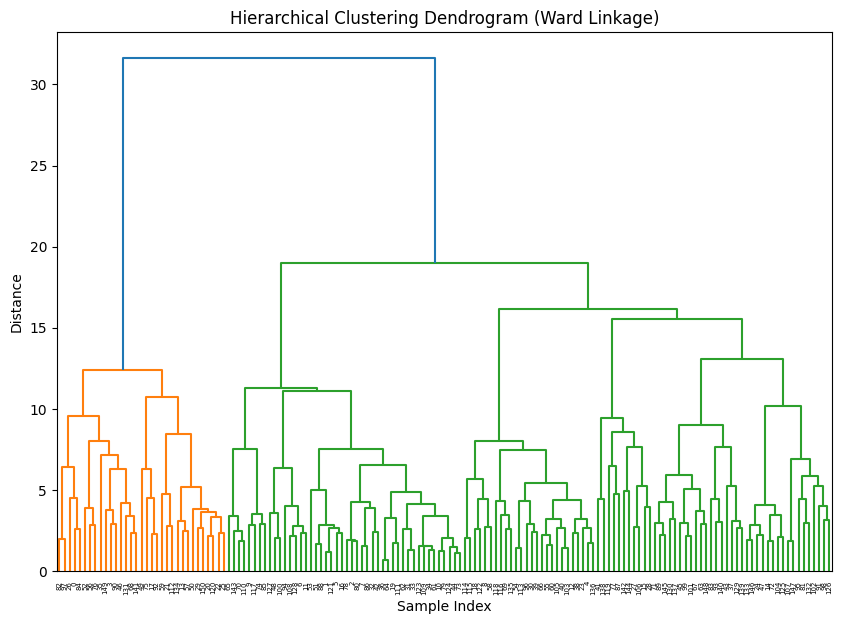

In [230]:
# Step 2: Create dendrogram using SCALED data (for consistency)
linked = linkage(x_scaled, method='ward')

plt.figure(figsize=(10, 7))  # Optional: set figure size
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [231]:
# Step 3: Apply Agglomerative Clustering using SCALED data
from sklearn.cluster import AgglomerativeClustering

agc = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels = agc.fit_predict(x_scaled)

print(f"Total clusters: {len(np.unique(labels))}")
print(f"Cluster distribution: {np.bincount(labels)}")

Total clusters: 6
Cluster distribution: [33 17 46 26 11 18]


In [232]:
# Display scaled data
print("Scaled data shape:", x_scaled.shape)

Scaled data shape: (151, 17)


In [233]:
x_scaled

array([[-0.51059087,  0.94256934,  0.88555152, ...,  0.93666669,
         0.63070804,  0.75743246],
       [-0.19269963,  0.23871877, -0.59690124, ...,  1.18729403,
         0.92900187,  0.06446167],
       [ 0.2240911 ,  0.09325632, -0.66414258, ..., -0.41589241,
         0.9849438 , -0.20733176],
       ...,
       [-0.53884787,  0.30910382,  0.59009384, ...,  1.30742945,
        -0.12953259,  0.4776654 ],
       [-0.75783961, -0.27743832,  1.124244  , ...,  1.000877  ,
        -1.31566784,  0.1764206 ],
       [-0.66600437,  0.18241072,  0.26384733, ..., -0.3413256 ,
        -1.55885795,  0.19545005]], shape=(151, 17))

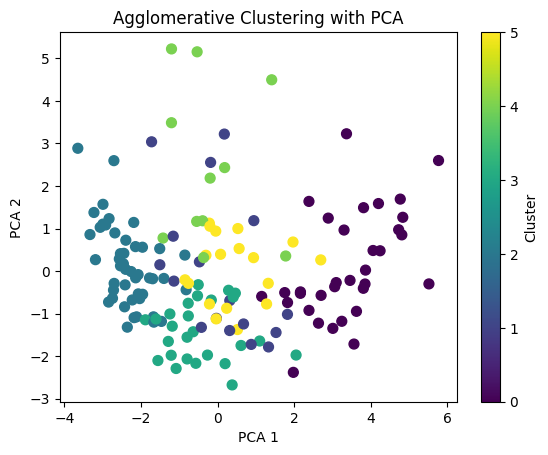

In [234]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Agglomerative Clustering with PCA')
plt.colorbar(label='Cluster')
plt.show()